# 📊 Unemployment Analysis in India Using Python

## Project Overview

This project focuses on analyzing unemployment trends in India using Python. The dataset contains unemployment statistics across different states and regions of India, including unemployment rate, labour participation rate, employment estimates, area type, and date.

The analysis aims to clean the dataset, explore unemployment patterns, visualize trends, and examine the impact of the Covid-19 pandemic on unemployment.

## Objectives

- Load and clean the unemployment dataset.
- Perform exploratory data analysis (EDA).
- Visualize unemployment trends across different regions.
- Analyze the impact of Covid-19 on unemployment rates.
- Identify important patterns and seasonal trends.
- Present insights that may support economic and social policy decisions.

## Tools and Libraries Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Dataset

The dataset contains information about unemployment statistics in India, including:

- Region
- Date
- Estimated Unemployment Rate (%)
- Estimated Employed
- Estimated Labour Participation Rate (%)
- Area (Urban/Rural)

## Expected Outcome

After completing this project, we will be able to:

- Understand unemployment trends in India.
- Compare unemployment across different regions.
- Study the effect of Covid-19 on employment.
- Visualize data using various charts.
- Draw meaningful conclusions from the analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv("Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df.shape

(768, 7)

In [5]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [6]:
df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [8]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [9]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [10]:
df = df.dropna()

df.shape

(740, 7)

In [11]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


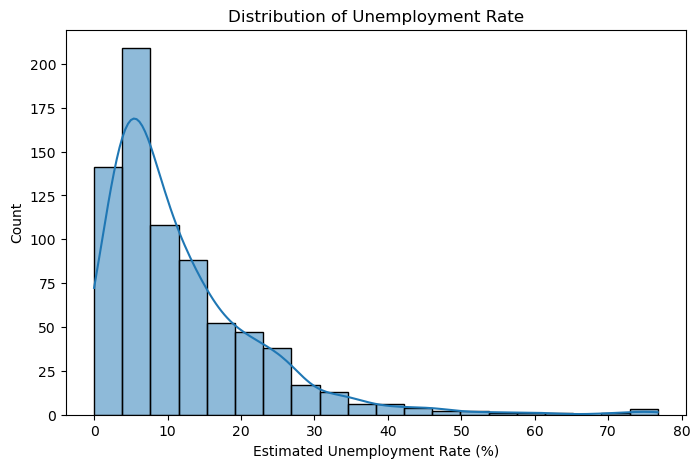

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Estimated Unemployment Rate (%)"],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")

plt.show()

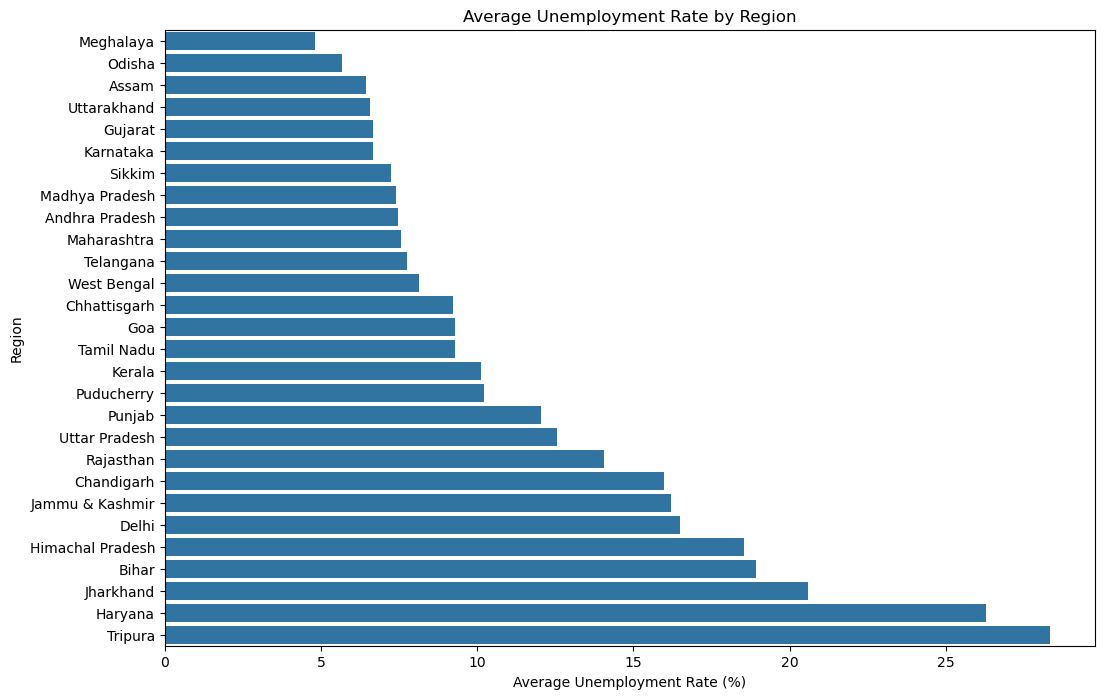

In [13]:
plt.figure(figsize=(12,8))

region = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values()

sns.barplot(
    x=region.values,
    y=region.index
)

plt.title("Average Unemployment Rate by Region")

plt.xlabel("Average Unemployment Rate (%)")

plt.ylabel("Region")

plt.show()

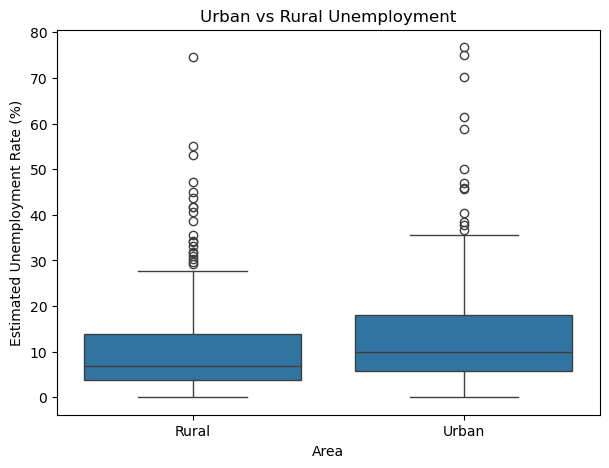

In [14]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Area",
    y="Estimated Unemployment Rate (%)",
    data=df
)

plt.title("Urban vs Rural Unemployment")

plt.show()

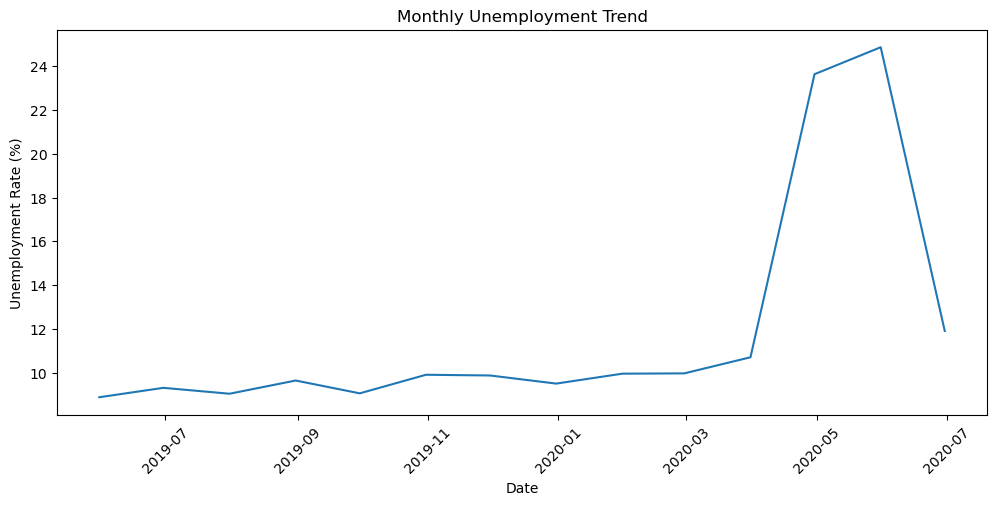

In [15]:
monthly = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(12,5))

plt.plot(monthly.index, monthly.values)

plt.title("Monthly Unemployment Trend")

plt.xlabel("Date")

plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

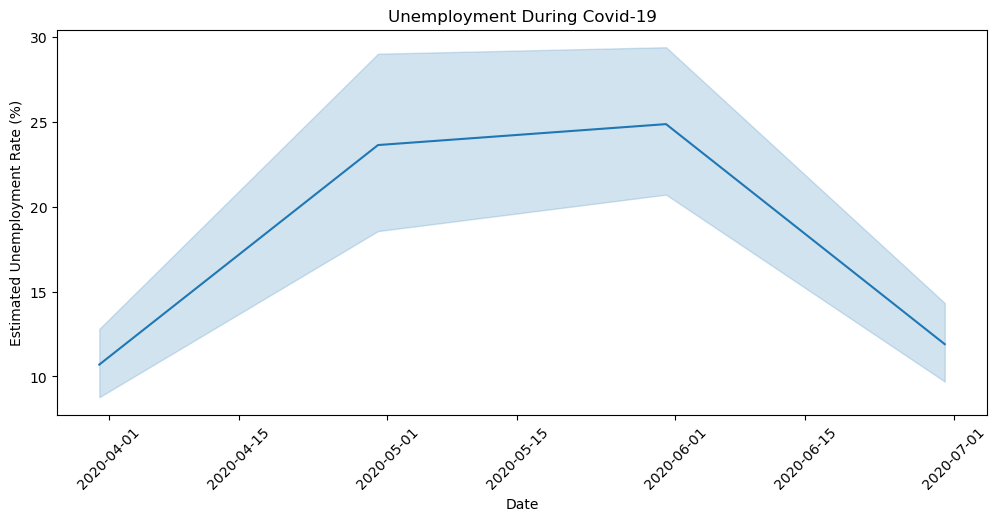

In [16]:
covid = df[df["Date"] >= "2020-03-01"]

plt.figure(figsize=(12,5))

sns.lineplot(
    x="Date",
    y="Estimated Unemployment Rate (%)",
    data=covid
)

plt.title("Unemployment During Covid-19")

plt.xticks(rotation=45)

plt.show()

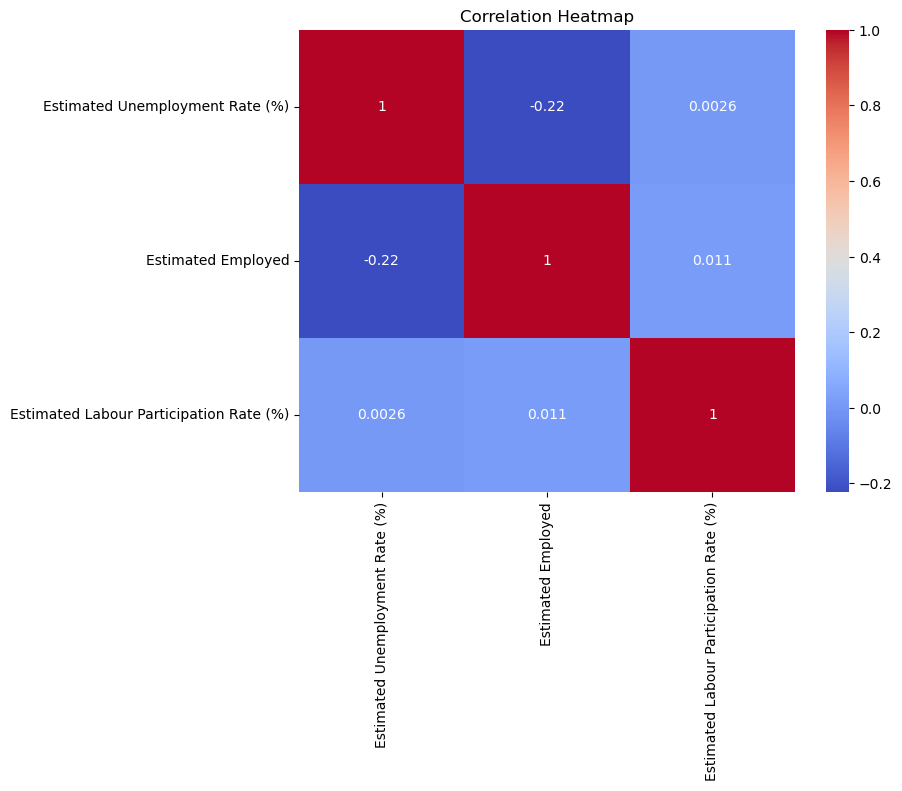

In [17]:
numeric = df.select_dtypes(include=["number"])
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Key Insights

- The unemployment rate varies across different regions of India.
- Urban and rural areas show different unemployment patterns.
- A significant increase in unemployment is observed during the Covid-19 period.
- Labour participation rate is related to employment and unemployment levels.
- Data visualization helps identify regional and temporal trends.